# =============================================================================
# HOUSING PRICE PREDICTION PIPELINE
# =============================================================================

# Importing Libraries and Data

In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

In [270]:
train_data=pd.read_csv(r"C:\Users\v\Downloads\archive (1)\train.csv")

In [271]:
train_data

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5
...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,78.043277,45.0
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,-86.150721,16.0
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,75.828002,27.1
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,80.227910,67.0


# EXPLORATORY DATA ANALYSIS (EDA)

In [272]:
# Basic statistics
train_data.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [273]:
# check duplicates
train_data.drop_duplicates()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5
...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,78.043277,45.0
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,-86.150721,16.0
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,75.828002,27.1
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,80.227910,67.0


In [274]:
# Remove duplicates
train_data.drop_duplicates()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5
...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,78.043277,45.0
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,-86.150721,16.0
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,75.828002,27.1
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,80.227910,67.0


In [275]:
#check missing data
train_data.isna().sum()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

In [276]:
#check data types
train_data.dtypes

POSTED_BY                 object
UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
BHK_OR_RK                 object
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
ADDRESS                   object
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
dtype: object

# FEATURE ENGINEERING

In [277]:
# Extract Area and City from ADDRESS
train_data["Area"]=train_data['ADDRESS'].str.split(",").str[0]
train_data["city"]=train_data['ADDRESS'].str.split(",").str[1]
train_data

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),Area,city
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0,Ksfc Layout,Bangalore
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0,Vishweshwara Nagar,Mysore
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0,Jigani,Bangalore
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5,Sector-1 Vaishali,Ghaziabad
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5,New Town,Kolkata
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,78.043277,45.0,Shamshabad Road,Agra
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,-86.150721,16.0,E3-108,Lake View Recidency
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,75.828002,27.1,Ajmer Road,Jaipur
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,80.227910,67.0,Sholinganallur,Chennai


In [278]:
train_data.nunique()

POSTED_BY                    3
UNDER_CONSTRUCTION           2
RERA                         2
BHK_NO.                     16
BHK_OR_RK                    2
SQUARE_FT                19561
READY_TO_MOVE                2
RESALE                       2
ADDRESS                   6899
LONGITUDE                 4087
LATITUDE                  4078
TARGET(PRICE_IN_LACS)     1172
Area                      5884
city                       433
dtype: int64

In [279]:
# Create Location Tiers using KMeans Clustering
from sklearn.cluster import KMeans

# Create 10 clusters directly for 10 tiers
kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(train_data[['LATITUDE', 'LONGITUDE']])

# Direct mapping to tier labels with "tier" prefix
tier_mapping = {0: 'tier1', 1: 'tier2', 2: 'tier3', 3: 'tier4', 4: 'tier5', 
                5: 'tier6', 6: 'tier7', 7: 'tier8', 8: 'tier9', 9: 'tier10'}
train_data['loc_tier'] = cluster_labels
train_data['loc_tier'] = train_data['loc_tier'].map(tier_mapping).astype('object')

print("Direct tier assignment tier1-tier10:")
print(train_data['loc_tier'].value_counts().sort_index())

C:\Users\v\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Direct tier assignment tier1-tier10:
loc_tier
tier1     3483
tier10       4
tier2       77
tier3     8953
tier4     2789
tier5     6314
tier6       76
tier7       77
tier8     1302
tier9     6376
Name: count, dtype: int64


In [280]:
# Create dummy variables for location tiers
train_data = pd.get_dummies(train_data, columns=['loc_tier'], dtype=int)
train_data

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,...,loc_tier_tier1,loc_tier_tier10,loc_tier_tier2,loc_tier_tier3,loc_tier_tier4,loc_tier_tier5,loc_tier_tier6,loc_tier_tier7,loc_tier_tier8,loc_tier_tier9
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,...,0,0,0,0,0,1,0,0,0,0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,...,0,0,0,0,0,1,0,0,0,0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,...,0,0,0,0,0,1,0,0,0,0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,...,0,0,0,0,0,0,0,0,0,1
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,...,1,0,0,0,0,0,0,0,0,0
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,...,0,0,1,0,0,0,0,0,0,0
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,...,1,0,0,0,0,0,0,0,0,0
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,...,0,0,0,0,0,1,0,0,0,0


In [281]:
# Label Encoding for categorical variables
le = LabelEncoder()
train_data['POSTED_BY_num'] = le.fit_transform(train_data['POSTED_BY'])
train_data['city_num'] = le.fit_transform(train_data['city'])

# DATA VISUALIZATION

In [282]:
Numerical_data=train_data.select_dtypes(include=['int64','float64', "int32"])

In [283]:
Numerical_data.dtypes

UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
loc_tier_tier1             int32
loc_tier_tier10            int32
loc_tier_tier2             int32
loc_tier_tier3             int32
loc_tier_tier4             int32
loc_tier_tier5             int32
loc_tier_tier6             int32
loc_tier_tier7             int32
loc_tier_tier8             int32
loc_tier_tier9             int32
POSTED_BY_num              int32
city_num                   int32
dtype: object

In [284]:
# Correlation Matrix
corr=Numerical_data.corr()
corr


,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),loc_tier_tier1,...,loc_tier_tier2,loc_tier_tier3,loc_tier_tier4,loc_tier_tier5,loc_tier_tier6,loc_tier_tier7,loc_tier_tier8,loc_tier_tier9,POSTED_BY_num,city_num
UNDER_CONSTRUCTION,1.000000,0.363826,-0.040712,-0.004204,-1.000000,-0.347405,0.006440,-0.000381,0.055399,0.006821,...,-0.003188,0.070292,0.024360,-0.070454,-0.016840,-0.017042,0.017189,-0.034809,-0.263473,0.071435
RERA,0.363826,1.000000,0.009547,-0.006229,-0.363826,-0.270351,0.104976,-0.065106,0.067636,0.045994,...,-0.017820,0.093952,-0.189431,-0.106129,-0.021791,-0.024959,-0.057440,0.136315,-0.285316,0.059725
BHK_NO.,-0.040712,0.009547,1.000000,0.005303,0.040712,0.014581,0.068730,0.046930,0.112283,-0.026591,...,-0.000912,-0.188103,0.061201,0.059402,0.002426,0.010434,-0.012166,0.132782,-0.072466,-0.086146
SQUARE_FT,-0.004204,-0.006229,0.005303,1.000000,0.004204,0.001732,-0.012591,0.000803,0.402685,-0.003511,...,-0.000498,-0.006324,-0.003101,0.018080,-0.000493,-0.000492,-0.002053,-0.004784,0.005415,-0.013557
READY_TO_MOVE,-1.000000,-0.363826,0.040712,0.004204,1.000000,0.347405,-0.006440,0.000381,-0.055399,-0.006821,...,0.003188,-0.070292,-0.024360,0.070454,0.016840,0.017042,-0.017189,0.034809,0.263473,-0.071435
RESALE,-0.347405,-0.270351,0.014581,0.001732,0.347405,1.000000,0.024038,0.014844,-0.207378,-0.018378,...,-0.004100,-0.050348,0.024206,0.012497,0.014000,0.008894,0.002382,0.037382,0.332280,-0.020459
LONGITUDE,0.006440,0.104976,0.068730,-0.012591,-0.006440,0.024038,1.000000,-0.155062,-0.031112,0.245945,...,0.164230,-0.205278,0.082632,-0.720993,0.218296,0.110272,-0.055337,0.665821,-0.049164,0.222619
LATITUDE,-0.000381,-0.065106,0.046930,0.000803,0.000381,0.014844,-0.155062,1.000000,-0.017254,0.021687,...,-0.801135,-0.228257,0.335093,0.056193,-0.330914,0.282165,0.062539,0.015409,0.025425,-0.078504
TARGET(PRICE_IN_LACS),0.055399,0.067636,0.112283,0.402685,-0.055399,-0.207378,-0.031112,-0.017254,1.000000,-0.019783,...,-0.002296,0.056466,-0.028057,0.004053,-0.004486,-0.002722,-0.023862,-0.018530,-0.093328,0.006942
loc_tier_tier1,0.006821,0.045994,-0.026591,-0.003511,-0.006821,-0.018378,0.245945,0.021687,-0.019783,1.000000,...,-0.018751,-0.242039,-0.118450,-0.191318,-0.018628,-0.018751,-0.078765,-0.192513,-0.016060,-0.013194


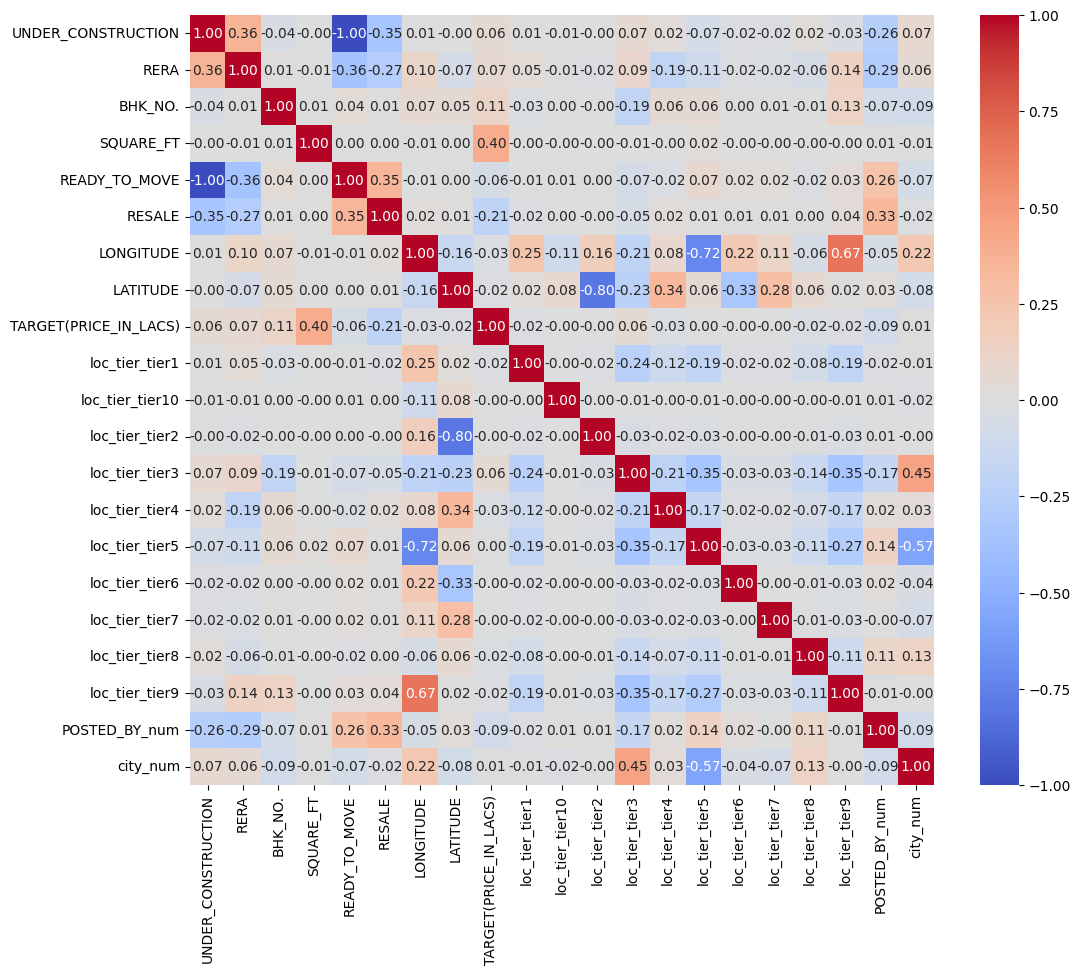

In [285]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

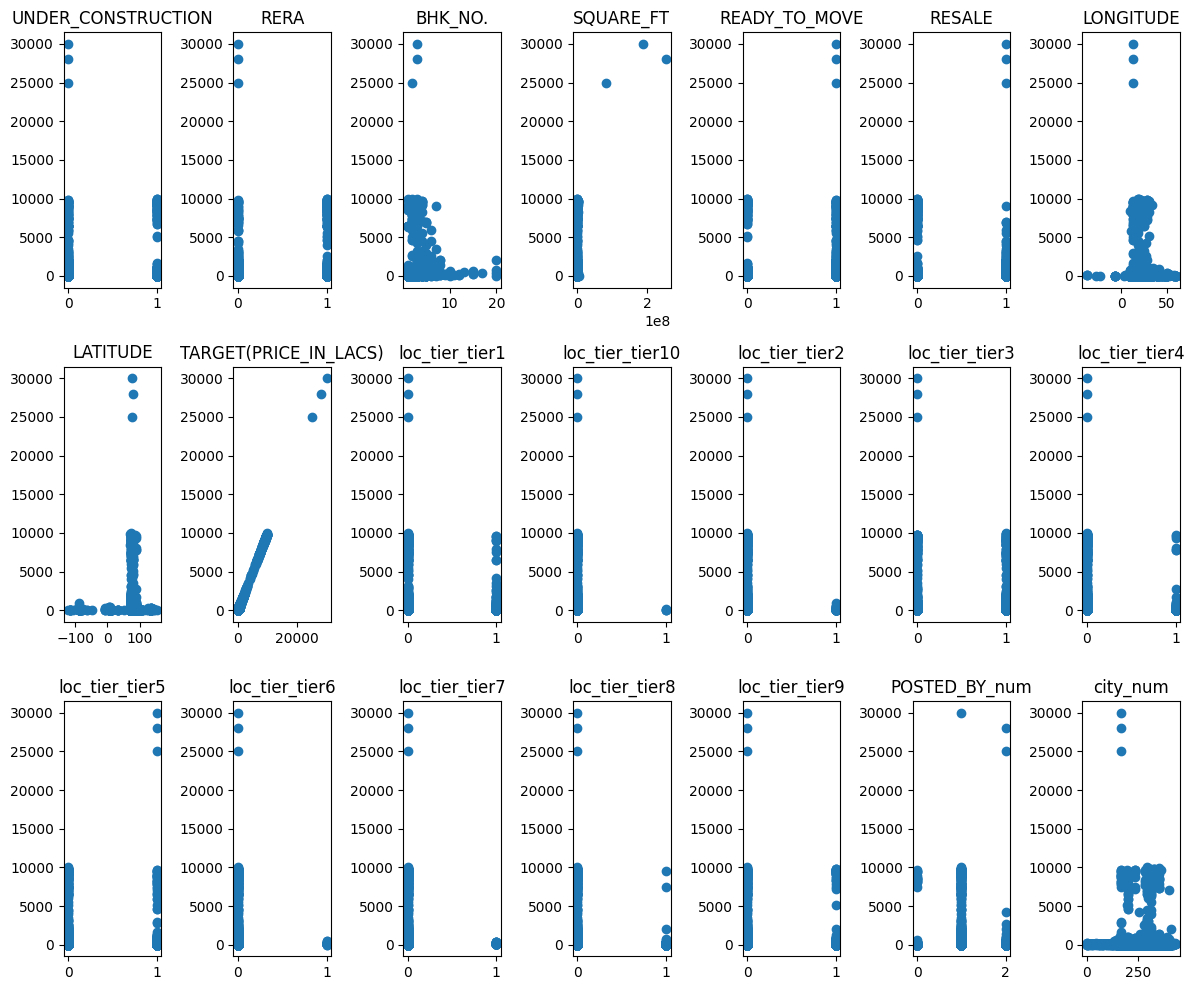

In [286]:
#check Data Linearity
fig,axe=plt.subplots(3,7,figsize=(12, 10))
axe=axe.ravel()
for index,col in enumerate (Numerical_data):
    axe[index].scatter(Numerical_data[col],Numerical_data['TARGET(PRICE_IN_LACS)'])
    axe[index].set_title(f"{col}")
plt.tight_layout()
plt.show()

In [287]:
X=Numerical_data.drop(['UNDER_CONSTRUCTION','LONGITUDE', 'LATITUDE','city_num','TARGET(PRICE_IN_LACS)'],axis=1)
X

,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,loc_tier_tier1,loc_tier_tier10,loc_tier_tier2,loc_tier_tier3,loc_tier_tier4,loc_tier_tier5,loc_tier_tier6,loc_tier_tier7,loc_tier_tier8,loc_tier_tier9,POSTED_BY_num
0,0,2,1300.236407,1,1,0,0,0,0,0,1,0,0,0,0,2
1,0,2,1275.000000,1,1,0,0,0,0,0,1,0,0,0,0,1
2,0,2,933.159722,1,1,0,0,0,0,0,1,0,0,0,0,2
3,1,2,929.921143,1,1,0,0,0,0,0,0,0,0,0,1,2
4,0,2,999.009247,0,1,0,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29446,0,3,2500.000000,1,1,1,0,0,0,0,0,0,0,0,0,2
29447,0,2,769.230769,1,1,0,0,1,0,0,0,0,0,0,0,2
29448,0,2,1022.641509,1,1,1,0,0,0,0,0,0,0,0,0,1
29449,0,2,927.079009,1,1,0,0,0,0,0,1,0,0,0,0,2


In [288]:
y=train_data['TARGET(PRICE_IN_LACS)']

# OUTLIER DETECTION AND REMOVAL

In [290]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor()
outlier_labels = lof.fit_predict(X)
# Create boolean mask
outlier_mask = outlier_labels == -1
inlier_mask = outlier_labels == 1

# Filter data
X_clean = X[inlier_mask]  # Data without outliers
y_clean = y[inlier_mask]  # Target without outliers

X_outliers_only = X[outlier_mask]  # Only outliers
X_inliers = X[inlier_mask]  # Only outliers

def remove_all_outliers(X, y=None, contamination=0.1, method='lof'):
    """
    Remove all outliers from dataset
    
    Parameters:
    X: features DataFrame
    y: target Series (optional)
    contamination: expected outlier proportion
    method: 'lof' for Local Outlier Factor
    """
    
    if method == 'lof':
        lof = LocalOutlierFactor(contamination=contamination, n_neighbors=20)
        outlier_labels = lof.fit_predict(X)
    
    # Keep only inliers (label == 1)
    inlier_mask = outlier_labels == 1
    
    X_clean = X[inlier_mask]
    
    if y is not None:
        y_clean = y[inlier_mask]
        return X_clean, y_clean
    else:
        return X_clean

# Usage
X_clean, y_clean = remove_all_outliers(X, y, contamination=0.1)

# DATA PREPROCESSING

In [291]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Initialize scaler
scaler = StandardScaler()

#Fit and transform X (all features)
X_scaled = scaler.fit_transform(X_clean)

# Now split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.3, random_state=42)

# MODEL TRAINING AND EVALUATION

In [292]:

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """
    Unified function to train and evaluate any model
    """
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Print formatted results
    print(f"┌{'─' * 60}┐")
    print(f"│ {model_name:^58} │")
    print(f"├{'─' * 60}┤")
    print(f"│ MSE:  {mse:>44.2f} │")
    print(f"│ RMSE: {rmse:>44.2f} │")
    print(f"│ R²:   {r2:>44.4f} │")
    print(f"└{'─' * 60}┘")
    print()
    
    return {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'R²': r2, 'Predictions': y_pred}

# Initialize models
print("🚀 INITIALIZING MODELS...")
print("=" * 70)

# 1. Linear Regression
lr = LinearRegression()

# 2. Decision Tree (Optimized)
dt = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# 3. Stacking Ensemble
models = [("Linear Regression", lr), ("Decision Tree", dt)]
meta_learner = LinearRegression()
stacking_reg = StackingRegressor(estimators=models, final_estimator=meta_learner)

# 4. Random Forest (Optimized)
rf = RandomForestRegressor(
    n_estimators=100,  # Increased from 50
    max_depth=15,      # Increased from 10
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1  # Use all cores
)

# Evaluate all models
results = []

print("\n📊 MODEL PERFORMANCE COMPARISON")
print("=" * 70)

# Linear Regression
lr_results = evaluate_model(lr, "Linear Regression", X_train, y_train, X_test, y_test)
results.append(lr_results)

# Decision Tree
dt_results = evaluate_model(dt, "Decision Tree", X_train, y_train, X_test, y_test)
results.append(dt_results)

# Stacking Ensemble
stacking_results = evaluate_model(stacking_reg, "Stacking Ensemble", X_train, y_train, X_test, y_test)
results.append(stacking_results)

# Random Forest
rf_results = evaluate_model(rf, "Random Forest", X_train, y_train, X_test, y_test)
results.append(rf_results)

# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df[['Model', 'R²', 'MSE', 'RMSE']]

print("🎯 FINAL COMPARISON TABLE")
print("=" * 70)
print(results_df.round(4).to_string(index=False))

🚀 INITIALIZING MODELS...

📊 MODEL PERFORMANCE COMPARISON
┌────────────────────────────────────────────────────────────┐
│                     Linear Regression                      │
├────────────────────────────────────────────────────────────┤
│ MSE:                                      65202.22 │
│ RMSE:                                       255.35 │
│ R²:                                         0.7905 │
└────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────┐
│                       Decision Tree                        │
├────────────────────────────────────────────────────────────┤
│ MSE:                                      39040.26 │
│ RMSE:                                       197.59 │
│ R²:                                         0.8746 │
└────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────┐
│                     Stacking Ensemble     